# 1. Purpose

This notebook runs the **Cascaded Speech-to-Text Translation (ST) pipeline** for the COMPSCI 760 research project investigating **regional English accent sensitivity in Direct and Cascaded speech translation systems**.

The Cascaded system follows:

**English audio → Whisper large-v2 ASR → English transcript → NLLB-200 3.3B → Simplified Chinese translation**

The purpose of this notebook is **inference and reproducible result generation only**. It processes the same frozen audio samples used by the Direct pipeline and produces the outputs required for later translation-quality and statistical evaluation.

The notebook supports two dataset modes:

- **Pilot:** a small subset used to validate the complete pipeline before the final experiment.
- **Final:** the full evaluation dataset containing **4,200 audio clips across 7 regional English accent groups, with 600 clips per group**.

No model fine-tuning, accent-specific adaptation, speech enhancement, manual transcript correction, or manual translation correction is performed. All samples are processed using the same frozen pretrained models, audio preprocessing, language settings, precision, and deterministic decoding configuration.

The Cascaded pipeline produces two prediction fields:

1. `asr_transcript` — the actual English transcript generated by Whisper large-v2. This is preserved for later **WER analysis** against the Common Voice source transcript.
2. `cascade_translation` — the Simplified Chinese translation generated by NLLB from the Whisper transcript. This is preserved for later **chrF++ and BLEU evaluation** against the frozen Chinese reference translation.

The ground-truth source transcript is **not** provided to NLLB. NLLB receives only the transcript generated by Whisper, preserving the true Cascaded architecture and allowing downstream analysis of how ASR errors may propagate into translation quality.

The notebook mirrors the experimental controls used by `03_direct_pipeline.ipynb`, including:

- the same pilot/final dataset selection;
- the same frozen audio samples and sample identifiers;
- strict metadata and audio validation;
- reproducibility fingerprints and exact model revisions;
- fixed inference settings across all accent groups;
- checkpoint and recovery support;
- per-sample runtime and generation diagnostics;
- hardware/software environment recording;
- generation-failure and degenerate-ASR detection;
- final output-integrity validation.

Whisper and NLLB are executed as two staged inference passes:

**Pass A:** all audio clips are transcribed using Whisper large-v2.

**Pass B:** all successful Whisper transcripts are translated into Simplified Chinese using NLLB-200 3.3B.

The staged execution reduces peak GPU-memory requirements while preserving the logical Cascaded system:

**Speech → ASR → Machine Translation**

Runtime is recorded separately for the Whisper and NLLB stages. The reported combined Cascade runtime is the **sum of the measured per-sample Whisper and NLLB stage runtimes**; model loading and warm-up are excluded. This value is treated as a computational diagnostic rather than a true simultaneously measured end-to-end request latency.

This notebook does **not** calculate WER, chrF++, BLEU, Direct–Cascade performance gaps, confidence intervals, correlations, statistical significance tests, or accent-performance conclusions. These analyses are intentionally performed in separate downstream evaluation and statistical-analysis notebooks.

The final outputs from this notebook are therefore the **frozen Cascaded-system predictions and reproducibility diagnostics** required for the later paired comparison with the Direct SeamlessM4T v2-large system.

# 2. Install and Import Required Libraries

The first code cell installs/imports the libraries needed for the same notebook workflow as the Direct pipeline, plus the Hugging Face model classes required for Whisper ASR and NLLB translation.

If your environment is already configured and stable, avoid changing package versions immediately before or during the official 4,200-sample experiment.


In [3]:
%pip install -q "transformers==4.57.6" sentencepiece pandas numpy tqdm matplotlib psutil huggingface_hub "accelerate>=0.26,<2"
%pip install torch==2.11.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu130
%pip install -U protobuf sentencepiece
%pip install hf_xet
%pip install torchcodec==0.11

import gc
import hashlib
import json
import platform
import random
import subprocess
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
import torchaudio
import transformers
from huggingface_hub import HfApi
from tqdm.notebook import tqdm
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoProcessor,
    AutoTokenizer,
    WhisperForConditionalGeneration,
)

print("Libraries imported successfully.")


Looking in indexes: https://download.pytorch.org/whl/cu130
Libraries imported successfully.


# 3. Constants and Configuration

This is the only experiment-configuration cell. To switch datasets, change only:

```python
DATASET_MODE = "pilot"
```

to:

```python
DATASET_MODE = "final"
```

The Cascade uses fixed model, language, preprocessing, and deterministic decoding settings for every sample and accent group.

Model revisions are resolved to exact Hugging Face commit SHAs and recorded. After the pilot is approved, you can replace `"main"` with those printed SHAs before the official final run to freeze them completely.

For the final dataset, strict checks expect **4,200 clips = 7 accent groups × 600 clips/group**.

Use a fresh run for the 3.3B model (`RESUME_RUN_DIR = None`); do not resume a previous 600M run.


In [4]:
DATASET_MODE = "final"  # Change only this to "final" for the final dataset.

# PROJECT_ROOT is one directory above the notebook directory.
PROJECT_ROOT = Path.cwd().resolve()
print(f'Project root resolved to: {PROJECT_ROOT}')

PILOT_METADATA_PATH = Path(PROJECT_ROOT) / "data/pilot_sample/pilot_sample_metadata.csv"
PILOT_AUDIO_DIR = Path(PROJECT_ROOT) / "data/pilot_sample/pilot_sample_audio"
FINAL_METADATA_PATH = Path(PROJECT_ROOT) / "data/final_sample/final_sample_600_per_group.csv"
FINAL_AUDIO_DIR = Path(PROJECT_ROOT) / "data/final_sample/final_sample_audio"

# Cascaded architecture.
WHISPER_MODEL_ID = "openai/whisper-large-v2"
WHISPER_MODEL_REVISION = "main"  # Resolve during pilot, then optionally freeze the printed SHA.
WHISPER_MODEL_CLASS_NAME = "WhisperForConditionalGeneration"
WHISPER_LANGUAGE = "en"
WHISPER_TASK = "transcribe"
WHISPER_ATTENTION_IMPLEMENTATION = "eager"  # Use "eager" for Whisper to avoid potential issues with SDPA in certain environments.

NLLB_MODEL_ID = "facebook/nllb-200-3.3B"
NLLB_MODEL_REVISION = "main"  # Resolve during pilot, then optionally freeze the printed SHA.
NLLB_MODEL_CLASS_NAME = "AutoModelForSeq2SeqLM"
NLLB_SOURCE_LANGUAGE = "eng_Latn"
NLLB_TARGET_LANGUAGE = "zho_Hans"
NLLB_ATTENTION_IMPLEMENTATION = "sdpa" # Use "sdpa" for NLLB to leverage the optimized scaled dot-product attention implementation.

OUTPUT_BASE_DIR = Path(PROJECT_ROOT) / "runs"
CHECKPOINT_EVERY = 10
SEED = 760
RESUME_RUN_DIR = None  # Example: Path("../runs/cascade_run_1780000000")

# Final evaluation-set invariants.
EXPECTED_FINAL_SAMPLES = 4200
EXPECTED_FINAL_ACCENT_GROUPS = 7
EXPECTED_FINAL_SAMPLES_PER_ACCENT = 600

# Fixed deterministic decoding policy.
# Do not tune these by accent or after inspecting final results.
# Use greedy decoding (do_sample=False) for deterministic output, and set num_beams=1 for greedy search.
WHISPER_GENERATION_KWARGS = {
    "num_beams": 1, # Number of beams for beam search. Higher values may improve accuracy but increase computation time.
    "do_sample": False, # Whether to use sampling; if False, uses greedy decoding. Set to False for deterministic output.
    "max_new_tokens": 256, # Maximum number of new tokens to generate. Adjust based on expected output length.
}
NLLB_GENERATION_KWARGS = {
    "num_beams": 1, # Number of beams for beam search. Higher values may improve accuracy but increase computation time.
    "do_sample": False, # Whether to use sampling; if False, uses greedy decoding. Set to False for deterministic output.
    "max_new_tokens": 256, # Maximum number of new tokens to generate. Adjust based on expected output length.
}

DECODING_POLICY_NOTE = (
    "Fixed deterministic greedy decoding for Whisper ASR and NLLB MT, "
    "pre-specified before final evaluation and identical for every clip/accent group."
)
EXECUTION_STRATEGY = (
    "staged: run Whisper for all samples, release Whisper GPU memory, "
    "then run NLLB for all successful ASR transcripts"
)

DATASET_PATHS = {
    "pilot": (PILOT_METADATA_PATH, PILOT_AUDIO_DIR),
    "final": (FINAL_METADATA_PATH, FINAL_AUDIO_DIR),
}
if DATASET_MODE not in DATASET_PATHS:
    raise ValueError(f"DATASET_MODE must be one of {list(DATASET_PATHS)}, not {DATASET_MODE!r}.")
METADATA_PATH, AUDIO_DIR = DATASET_PATHS[DATASET_MODE]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Dataset mode: {DATASET_MODE}")
print(f"Metadata: {METADATA_PATH}")
print(f"Audio directory: {AUDIO_DIR}")
print(f"Whisper: {WHISPER_MODEL_ID}")
print(f"NLLB: {NLLB_MODEL_ID}")
print(f"Whisper mode: language={WHISPER_LANGUAGE}, task={WHISPER_TASK}")
print(f"NLLB direction: {NLLB_SOURCE_LANGUAGE} → {NLLB_TARGET_LANGUAGE}")
print(f"Execution strategy: {EXECUTION_STRATEGY}")


Project root resolved to: /content
Dataset mode: final
Metadata: /content/data/final_sample/final_sample_600_per_group.csv
Audio directory: /content/data/final_sample/final_sample_audio
Whisper: openai/whisper-large-v2
NLLB: facebook/nllb-200-3.3B
Whisper mode: language=en, task=transcribe
NLLB direction: eng_Latn → zho_Hans
Execution strategy: staged: run Whisper for all samples, release Whisper GPU memory, then run NLLB for all successful ASR transcripts


# 4. Create Run Output Directory

Every fresh run creates:

```text
../runs/cascade_run_{unix_timestamp}/
```

The run directory contains the clean predictions, runtime/diagnostic table, environment/configuration records, summary JSON, and runtime figures.

Checkpoint files use the final filenames so the same run directory can be deliberately resumed.


In [5]:
RUN_TIMESTAMP = int(time.time())
RUN_STARTED_UTC = datetime.now(timezone.utc).isoformat()
RUN_DIR = Path(RESUME_RUN_DIR) if RESUME_RUN_DIR is not None else OUTPUT_BASE_DIR / f"cascade_run_{RUN_TIMESTAMP}"
RUN_DIR.mkdir(parents=True, exist_ok=RESUME_RUN_DIR is not None)

PREDICTIONS_PATH = RUN_DIR / "cascade_predictions.csv"
RUNTIME_PATH = RUN_DIR / "cascade_runtime.csv"
ENVIRONMENT_PATH = RUN_DIR / "run_environment.json"
CONFIG_PATH = RUN_DIR / "run_config.json"
SUMMARY_PATH = RUN_DIR / "run_summary.json"
RUNTIME_FIGURE_PATH = RUN_DIR / "runtime_per_clip.png"
DURATION_FIGURE_PATH = RUN_DIR / "runtime_vs_audio_duration.png"

print(f"Run directory: {RUN_DIR.resolve()}")


Run directory: /content/runs/cascade_run_1790228071


# 5. Hardware, Environment, and Reproducibility Information

This section mirrors the Direct notebook and records the software/hardware context needed to reproduce the run.

It resolves **both** requested Hugging Face model revisions to exact commit SHAs and records:

- Python / PyTorch / torchaudio / Transformers;
- CUDA and GPU information;
- CPU and RAM information;
- Git commit;
- Whisper/NLLB model IDs and revisions;
- language/task settings;
- fixed decoding settings;
- dataset paths;
- execution strategy.

Continuous CPU/GPU utilisation monitoring is intentionally not used because the research question concerns translation robustness rather than systems-efficiency benchmarking.


In [6]:
def get_git_commit():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"],
            stderr=subprocess.DEVNULL,
            text=True,
        ).strip()
    except Exception:
        return None

def get_gpu_driver_version():
    if not torch.cuda.is_available():
        return None
    try:
        return subprocess.check_output(
            ["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"],
            stderr=subprocess.DEVNULL,
            text=True,
        ).strip().splitlines()[0]
    except Exception:
        return None

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        while True:
            block = f.read(chunk_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()

def sha256_text_sequence(values):
    digest = hashlib.sha256()
    for value in values:
        digest.update(str(value).encode("utf-8"))
        digest.update(b"\n")
    return digest.hexdigest()

def resolve_model_revision(model_id, requested_revision):
    try:
        resolved = HfApi().model_info(model_id, revision=requested_revision).sha
        return resolved, bool(resolved)
    except Exception as exc:
        warnings.warn(
            f"Could not resolve {model_id} revision {requested_revision!r} "
            f"to an exact SHA. Proceeding with the requested revision. Error: {exc}"
        )
        return requested_revision, False

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")
MODEL_DTYPE = torch.float16 if CUDA_AVAILABLE else torch.float32
GPU_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None
GPU_MEMORY_GB = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2) if CUDA_AVAILABLE else None
GPU_DRIVER_VERSION = get_gpu_driver_version()

CPU_MODEL = platform.processor() or platform.uname().processor or platform.machine()
CPU_PHYSICAL_CORES = psutil.cpu_count(logical=False)
CPU_LOGICAL_CORES = psutil.cpu_count(logical=True)
SYSTEM_RAM_GB = round(psutil.virtual_memory().total / 1024**3, 2)
GIT_COMMIT = get_git_commit()

RESOLVED_WHISPER_REVISION, WHISPER_REVISION_IS_EXACT = resolve_model_revision(
    WHISPER_MODEL_ID, WHISPER_MODEL_REVISION
)
RESOLVED_NLLB_REVISION, NLLB_REVISION_IS_EXACT = resolve_model_revision(
    NLLB_MODEL_ID, NLLB_MODEL_REVISION
)

environment_info = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_started_utc": RUN_STARTED_UTC,
    "python_version": sys.version,
    "pytorch_version": torch.__version__,
    "torchaudio_version": torchaudio.__version__,
    "transformers_version": transformers.__version__,
    "cuda_available": CUDA_AVAILABLE,
    "cuda_version": torch.version.cuda,
    "device": str(DEVICE),
    "model_dtype": str(MODEL_DTYPE),
    "gpu_name": GPU_NAME,
    "gpu_memory_gb": GPU_MEMORY_GB,
    "gpu_driver_version": GPU_DRIVER_VERSION,
    "cpu_model": CPU_MODEL,
    "cpu_physical_cores": CPU_PHYSICAL_CORES,
    "cpu_logical_cores": CPU_LOGICAL_CORES,
    "system_ram_gb": SYSTEM_RAM_GB,
    "platform": platform.platform(),
    "system": platform.system(),
    "git_commit": GIT_COMMIT,

    "architecture": "cascade_whisper_asr_then_nllb_mt",
    "execution_strategy": EXECUTION_STRATEGY,

    "whisper_model_id": WHISPER_MODEL_ID,
    "whisper_model_class": WHISPER_MODEL_CLASS_NAME,
    "requested_whisper_revision": WHISPER_MODEL_REVISION,
    "resolved_whisper_revision": RESOLVED_WHISPER_REVISION,
    "whisper_revision_is_exact_sha": WHISPER_REVISION_IS_EXACT,
    "whisper_language": WHISPER_LANGUAGE,
    "whisper_task": WHISPER_TASK,
    "whisper_generation_settings": WHISPER_GENERATION_KWARGS,
    "whisper_attention_implementation": WHISPER_ATTENTION_IMPLEMENTATION,

    "nllb_model_id": NLLB_MODEL_ID,
    "nllb_model_class": NLLB_MODEL_CLASS_NAME,
    "requested_nllb_revision": NLLB_MODEL_REVISION,
    "resolved_nllb_revision": RESOLVED_NLLB_REVISION,
    "nllb_revision_is_exact_sha": NLLB_REVISION_IS_EXACT,
    "nllb_source_language": NLLB_SOURCE_LANGUAGE,
    "nllb_target_language": NLLB_TARGET_LANGUAGE,
    "nllb_generation_settings": NLLB_GENERATION_KWARGS,
    "nllb_attention_implementation": NLLB_ATTENTION_IMPLEMENTATION,

    "decoding_policy_note": DECODING_POLICY_NOTE,
    "dataset_mode": DATASET_MODE,
    "metadata_path": str(METADATA_PATH.resolve()),
    "audio_directory": str(AUDIO_DIR.resolve()),
    "seed": SEED,
}

run_config = {
    "dataset_mode": DATASET_MODE,
    "pilot_metadata_path": str(PILOT_METADATA_PATH),
    "pilot_audio_dir": str(PILOT_AUDIO_DIR),
    "final_metadata_path": str(FINAL_METADATA_PATH),
    "final_audio_dir": str(FINAL_AUDIO_DIR),

    "architecture": "Whisper large-v2 ASR → NLLB-200 3.3B MT",
    "execution_strategy": EXECUTION_STRATEGY,

    "whisper_model_id": WHISPER_MODEL_ID,
    "requested_whisper_revision": WHISPER_MODEL_REVISION,
    "resolved_whisper_revision": RESOLVED_WHISPER_REVISION,
    "whisper_language": WHISPER_LANGUAGE,
    "whisper_task": WHISPER_TASK,
    "whisper_generation_settings": WHISPER_GENERATION_KWARGS,
    "whisper_attention_implementation": WHISPER_ATTENTION_IMPLEMENTATION,

    "nllb_model_id": NLLB_MODEL_ID,
    "requested_nllb_revision": NLLB_MODEL_REVISION,
    "resolved_nllb_revision": RESOLVED_NLLB_REVISION,
    "nllb_source_language": NLLB_SOURCE_LANGUAGE,
    "nllb_target_language": NLLB_TARGET_LANGUAGE,
    "nllb_generation_settings": NLLB_GENERATION_KWARGS,
    "nllb_attention_implementation": NLLB_ATTENTION_IMPLEMENTATION,

    "decoding_policy_note": DECODING_POLICY_NOTE,
    "expected_final_samples": EXPECTED_FINAL_SAMPLES,
    "expected_final_accent_groups": EXPECTED_FINAL_ACCENT_GROUPS,
    "expected_final_samples_per_accent": EXPECTED_FINAL_SAMPLES_PER_ACCENT,
    "checkpoint_every": CHECKPOINT_EVERY,
    "seed": SEED,
}

ENVIRONMENT_PATH.write_text(json.dumps(environment_info, indent=2, ensure_ascii=False), encoding="utf-8")
CONFIG_PATH.write_text(json.dumps(run_config, indent=2, ensure_ascii=False), encoding="utf-8")

for key, value in environment_info.items():
    print(f"{key}: {value}")

if not CUDA_AVAILABLE:
    warnings.warn(
        "CUDA is not available. Whisper large-v2 and NLLB inference will run on CPU and may be very slow."
    )
if not WHISPER_REVISION_IS_EXACT:
    warnings.warn("The exact Whisper revision was not resolved; note this limitation.")
if not NLLB_REVISION_IS_EXACT:
    warnings.warn("The exact NLLB revision was not resolved; note this limitation.")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


run_timestamp: 1790228071
run_started_utc: 2026-09-24T05:34:31.737721+00:00
python_version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
pytorch_version: 2.11.0+cu128
torchaudio_version: 2.11.0+cu128
transformers_version: 4.57.6
cuda_available: True
cuda_version: 12.8
device: cuda
model_dtype: torch.float16
gpu_name: Tesla T4
gpu_memory_gb: 14.56
gpu_driver_version: 580.82.07
cpu_model: x86_64
cpu_physical_cores: 1
cpu_logical_cores: 2
system_ram_gb: 12.67
platform: Linux-6.6.122+-x86_64-with-glibc2.39
system: Linux
git_commit: None
architecture: cascade_whisper_asr_then_nllb_mt
execution_strategy: staged: run Whisper for all samples, release Whisper GPU memory, then run NLLB for all successful ASR transcripts
whisper_model_id: openai/whisper-large-v2
whisper_model_class: WhisperForConditionalGeneration
requested_whisper_revision: main
resolved_whisper_revision: ae4642769ce2ad8fc292556ccea8e901f1530655
whisper_revision_is_exact_sha: True
whisper_language: en
whisper_task: transcr

# 6. Load, Fingerprint, and Strictly Validate Input Metadata

The selected CSV is loaded without renaming, deleting, reordering, or modifying source columns.

For all runs:

- `id` must be present, non-empty, and unique.
- `id` uniquely identifies each evaluation sample/audio clip.
- `sample_id` identifies the speaker and may therefore appear in multiple rows.
- Downstream Direct/Cascade pairing should use `id`.

For the final run, the notebook fails early unless it sees exactly:

- **4,200 rows**
- **7 accent groups**
- **600 rows per accent group**
- no fully duplicated rows

A SHA-256 fingerprint of the metadata file and ordered `sample_id` sequence is recorded for reproducibility.


In [7]:
if not METADATA_PATH.is_file():
    raise FileNotFoundError(f"Metadata CSV not found: {METADATA_PATH.resolve()}")
if not AUDIO_DIR.is_dir():
    raise NotADirectoryError(f"Audio directory not found: {AUDIO_DIR.resolve()}")

METADATA_SHA256_BEFORE = sha256_file(METADATA_PATH)

metadata_df = pd.read_csv(METADATA_PATH)
original_columns = metadata_df.columns.tolist()

if "direct_translation" in original_columns:
    raise ValueError("Input metadata already contains 'direct_translation'; refusing to overwrite it.")
if metadata_df.columns.duplicated().any():
    raise ValueError("Input metadata contains duplicate column names, so exact output preservation is ambiguous.")

# Create a unique sample-level ID.
metadata_df.insert(
    0,
    "id",
    [f"sample_{i:04d}" for i in range(1, len(metadata_df) + 1)]
)
if metadata_df["id"].isna().any():
    raise ValueError("id contains missing values.")
if metadata_df["id"].astype(str).str.strip().eq("").any():
    raise ValueError("id contains blank values.")
if not metadata_df["id"].is_unique:
    duplicates = metadata_df.loc[
        metadata_df["id"].duplicated(keep=False),
        "id"
    ].head(20).tolist()
    raise ValueError(
        f"id must be unique. Example duplicates: {duplicates}"
    )

# sample_id is treated as the speaker identifier.
if "sample_id" not in metadata_df.columns:
    raise KeyError("Required speaker identifier column 'sample_id' is missing.")
if metadata_df["sample_id"].isna().any():
    raise ValueError("sample_id contains missing values.")
if metadata_df["sample_id"].astype(str).str.strip().eq("").any():
    raise ValueError("sample_id contains blank values.")

ID_SHA256 = sha256_text_sequence(
    metadata_df["id"].astype(str).tolist()
)

FULL_DUPLICATE_ROWS = int(metadata_df.duplicated().sum())

if DATASET_MODE == "final":
    if len(metadata_df) != EXPECTED_FINAL_SAMPLES:
        raise ValueError(
            f"Final dataset must contain exactly {EXPECTED_FINAL_SAMPLES:,} rows, "
            f"but found {len(metadata_df):,}."
        )
    if FULL_DUPLICATE_ROWS != 0:
        raise ValueError(f"Final metadata contains {FULL_DUPLICATE_ROWS} fully duplicated rows.")
    if "primary_accent" not in metadata_df.columns:
        raise KeyError("Final dataset requires 'primary_accent' for the balanced 7-group design.")
    if metadata_df["primary_accent"].isna().any():
        raise ValueError("Final dataset contains missing primary_accent values.")

    final_accent_counts = metadata_df["primary_accent"].value_counts(dropna=False)
    if len(final_accent_counts) != EXPECTED_FINAL_ACCENT_GROUPS:
        raise ValueError(
            f"Final dataset must contain {EXPECTED_FINAL_ACCENT_GROUPS} accent groups, "
            f"but found {len(final_accent_counts)}."
        )
    if not final_accent_counts.eq(EXPECTED_FINAL_SAMPLES_PER_ACCENT).all():
        raise ValueError(
            "Final dataset is not balanced at "
            f"{EXPECTED_FINAL_SAMPLES_PER_ACCENT} clips per accent:\n{final_accent_counts}"
        )

print(f"Dataset mode: {DATASET_MODE}")
print(f"Total samples: {len(metadata_df):,}")
print(f"Columns ({len(original_columns)}): {original_columns}")
print(f"Fully duplicated rows: {FULL_DUPLICATE_ROWS:,}")
print(f"Metadata SHA-256: {METADATA_SHA256_BEFORE}")
print(f"Ordered id SHA-256: {ID_SHA256}")
print("id check: non-missing and unique ✓")
print(
    f"Unique speakers (sample_id): "
    f"{metadata_df['sample_id'].nunique():,}"
)

if "primary_accent" in metadata_df.columns:
    print("\nAccent counts:")
    display(metadata_df["primary_accent"].value_counts(dropna=False).rename("count").to_frame())

important_candidates = [
    "clip", "path", "audio", "sentence", "sentence_id", "client_id",
    "speaker_id", "primary_accent", "duration[ms]", "audio_duration_sec",
    "duration_sec", "duration", "sentence_len_words", "sentence_len_chars",
    "reference_translation_zh"
]
important_columns = [c for c in important_candidates if c in metadata_df.columns]
if important_columns:
    print("\nMissing values in important fields:")
    display(metadata_df[important_columns].isna().sum().rename("missing").to_frame())

duration_column = next(
    (c for c in ["audio_duration_sec", "duration_sec", "duration", "duration[ms]"] if c in metadata_df.columns),
    None,
)
if duration_column:
    duration_values = pd.to_numeric(metadata_df[duration_column], errors="coerce")
    if duration_column == "duration[ms]":
        duration_values = duration_values / 1000.0
    print(f"\nDuration statistics in seconds from '{duration_column}':")
    display(duration_values.describe().to_frame("seconds"))

sentence_column = next((c for c in ["sentence", "text", "transcript"] if c in metadata_df.columns), None)
if sentence_column:
    sentence_lengths = metadata_df[sentence_column].fillna("").astype(str).str.split().str.len()
    print(f"\nSentence length statistics in words from '{sentence_column}':")
    display(sentence_lengths.describe().to_frame("word_count"))

# Add dataset fingerprints to reproducibility files.
environment_info.update({
    "metadata_sha256": METADATA_SHA256_BEFORE,
    "ordered_id_sha256": ID_SHA256,
    "dataset_rows": int(len(metadata_df)),
    "dataset_accent_groups": (
        int(metadata_df["primary_accent"].nunique())
        if "primary_accent" in metadata_df.columns
        else None
    ),
})
run_config.update({
    "metadata_sha256": METADATA_SHA256_BEFORE,
    "ordered_id_sha256": ID_SHA256,
    "dataset_rows": int(len(metadata_df)),
})
ENVIRONMENT_PATH.write_text(json.dumps(environment_info, indent=2, ensure_ascii=False), encoding="utf-8")
CONFIG_PATH.write_text(json.dumps(run_config, indent=2, ensure_ascii=False), encoding="utf-8")

display(metadata_df.head(5))


Dataset mode: final
Total samples: 4,200
Columns (21): ['path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment', 'primary_accent', 'sentence_norm', 'clip', 'duration[ms]', 'sentence_len_words', 'max_plausible_words', 'sentence_len_chars', 'sample_id', 'reference_translation_zh']
Fully duplicated rows: 0
Metadata SHA-256: 57fb7e6b62647d661cb887bdd279f1b4af57bbf1fca8e5ee741b5490136dcdba
Ordered id SHA-256: bf79323ce8acbf43a01d5dfb234b68b2e99fcb08d95671fd2bb2f9932c37f225
id check: non-missing and unique ✓
Unique speakers (sample_id): 1,586

Accent counts:


,count
primary_accent,
England English,600
Filipino,600
Hong Kong English,600
"India and South Asia (India, Pakistan, Sri Lanka)",600
Malaysian English,600
"Southern African (South Africa, Zimbabwe, Namibia)",600
United States English,600



Missing values in important fields:


,missing
clip,0
path,0
sentence,0
sentence_id,0
primary_accent,0
duration[ms],0
sentence_len_words,0
sentence_len_chars,0
reference_translation_zh,0



Duration statistics in seconds from 'duration[ms]':


,seconds
count,4200.000000
mean,4.619394
std,1.673903
min,1.728000
25%,3.288000
50%,4.392000
75%,5.736000
max,9.384000



Sentence length statistics in words from 'sentence':


,word_count
count,4200.000000
mean,8.985476
std,3.597587
min,2.000000
25%,6.000000
50%,9.000000
75%,12.000000
max,26.000000


,id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,...,segment,primary_accent,sentence_norm,clip,duration[ms],sentence_len_words,max_plausible_words,sentence_len_chars,sample_id,reference_translation_zh
0,sample_0001,common_voice_en_470969.mp3,011490baf5692eb45577c9673689ba64ea5042f8ed216f...,We talked of the side show in the circus.,NaN,2,0,fourties,male_masculine,England English,...,NaN,England English,we talked of the side show in the circus,common_voice_en_470969.mp3,3624,9,14.496,41,spk_1329,我们谈到了马戏团的杂耍表演。
1,sample_0002,common_voice_en_19670219.mp3,1de2845a12b84bcdfad2a954b83e79e5a54064eae0bce7...,"However, after persistent calls, Hall-Jones re...",NaN,2,0,twenties,female_feminine,England English,...,NaN,England English,however after persistent calls halljones reluc...,common_voice_en_19670219.mp3,9264,12,37.056,107,spk_1385,然而，经过不断的电话，Hall-Jones 还是不情愿地接受了，尽管他在议会里毫无野心。
2,sample_0003,common_voice_en_17262688.mp3,4933d68ff7a8bed9b55641bd748c0a15,What should I say?,NaN,2,0,twenties,male_masculine,England English,...,NaN,England English,what should i say,common_voice_en_17262688.mp3,2016,4,8.064,18,spk_0337,我该说什么？
3,sample_0004,common_voice_en_19057705.mp3,0dabc6a9640a139f548310fdd8306873589727eac1b584...,The rights to the film are currently in the pu...,NaN,2,0,twenties,female_feminine,England English,...,NaN,England English,the rights to the film are currently in the pu...,common_voice_en_19057705.mp3,4584,11,18.336,58,spk_1445,这部电影的版权目前属于公共领域。
4,sample_0005,common_voice_en_48612.mp3,ad82860cbbd707b2ef54935f72957bdb744a9034e5e7db...,Skiiers on a snowy mountain.,NaN,2,0,thirties,male_masculine,England English,...,NaN,England English,skiiers on a snowy mountain,common_voice_en_48612.mp3,2808,5,11.232,28,spk_1337,雪山上的滑雪者。


# 7. Resolve and Validate Audio Files

Audio paths are resolved exactly as in the Direct notebook without altering source metadata.

For the final 4,200-sample run, every expected audio file must exist and every resolved audio path must be unique. This ensures that the Direct and Cascaded systems can be paired on the same frozen sample IDs and audio clips.


In [8]:
AUDIO_COLUMN_CANDIDATES = ["clip", "path", "audio", "audio_file", "audio_filename", "filename", "file"]
AUDIO_COLUMN = next((c for c in AUDIO_COLUMN_CANDIDATES if c in metadata_df.columns), None)
if AUDIO_COLUMN is None:
    raise KeyError(f"No audio filename/path column found. Expected one of: {AUDIO_COLUMN_CANDIDATES}")

def resolve_audio_path(value):
    if pd.isna(value) or not str(value).strip():
        return None
    candidate = Path(str(value).strip()).expanduser()
    return candidate if candidate.is_absolute() else AUDIO_DIR / candidate

working_audio_paths = metadata_df[AUDIO_COLUMN].map(resolve_audio_path)
audio_exists = working_audio_paths.map(lambda p: p is not None and p.is_file())
missing_paths = working_audio_paths[~audio_exists]

resolved_audio_strings = working_audio_paths.map(
    lambda p: str(p.resolve()) if p is not None and p.exists() else None
)
duplicate_audio_mask = resolved_audio_strings.notna() & resolved_audio_strings.duplicated(keep=False)
duplicate_audio_count = int(duplicate_audio_mask.sum())

print(f"Audio column: {AUDIO_COLUMN}")
print(f"Valid audio files: {audio_exists.sum():,}")
print(f"Missing/unresolved audio files: {(~audio_exists).sum():,}")
print(f"Rows participating in duplicate resolved audio paths: {duplicate_audio_count:,}")

if len(missing_paths):
    display(pd.DataFrame({"row_index": missing_paths.index, "missing_audio": missing_paths.astype(str)}).head(50))

if duplicate_audio_count:
    display(
        pd.DataFrame({
            "row_index": metadata_df.index[duplicate_audio_mask],
            "id": metadata_df.loc[duplicate_audio_mask, "id"].values,
            "sample_id": metadata_df.loc[duplicate_audio_mask, "sample_id"].values,
            "resolved_audio": resolved_audio_strings[duplicate_audio_mask].values,
        }).head(50)
    )

if not audio_exists.any():
    raise FileNotFoundError("No valid audio files were resolved; inference cannot start.")

if DATASET_MODE == "final":
    if not audio_exists.all():
        raise FileNotFoundError(
            f"Final run requires all {EXPECTED_FINAL_SAMPLES:,} audio files. "
            f"Missing/unresolved: {(~audio_exists).sum():,}"
        )
    if duplicate_audio_count:
        raise ValueError(
            "Final run requires one unique audio path per sample. "
            f"Found {duplicate_audio_count} rows involved in duplicate paths."
        )


Audio column: clip
Valid audio files: 4,200
Missing/unresolved audio files: 0
Rows participating in duplicate resolved audio paths: 0


# 8. Timing Methodology

The Cascade records separate per-sample timing for both stages.

### Whisper stage
`whisper_runtime_sec` covers:

**audio loading → mono/resampling → Whisper processor → Whisper generation → transcript decoding**

`whisper_generation_runtime_sec` isolates `whisper_model.generate(...)`.

### NLLB stage
`nllb_runtime_sec` covers:

**transcript tokenization → NLLB generation → Chinese text decoding**

`nllb_generation_runtime_sec` isolates `nllb_model.generate(...)`.

### Combined Cascade timing
Because the two large models are intentionally run in staged passes for GPU-memory safety:

```text
cascade_stage_sum_runtime_sec
    = whisper_runtime_sec + nllb_runtime_sec
```

This is a sum of separately measured stage runtimes. It excludes model loading and warm-up and should **not** be described as a simultaneously resident, truly measured end-to-end request latency.

CUDA is synchronized around timed GPU work. Inference uses `torch.inference_mode()`.


In [9]:
def synchronize_device():
    if CUDA_AVAILABLE:
        torch.cuda.synchronize()

def release_cuda_memory():
    gc.collect()
    if CUDA_AVAILABLE:
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

print("Timing helpers ready.")


Timing helpers ready.


# 9. Load Cascaded Models

The Cascade contains two frozen pretrained models:

1. **Whisper large-v2** for English ASR;
2. **NLLB-200 3.3B** for English → Simplified Chinese text translation.

To match the available GPU-memory constraints, the models are **not held on the GPU simultaneously**. The notebook provides separate load/release helpers and records the exact revisions used.

The main run loads Whisper once for the ASR pass, releases it, then loads NLLB once for the MT pass. Model-loading time is excluded from per-sample timings.

NLLB uses Accelerate to place weights directly on the configured device during loading, reducing host RAM pressure compared with loading the entire model on CPU first. It retains FP16 on CUDA and does not automatically offload layers to CPU or disk.


In [10]:
def load_whisper():
    try:
        processor = AutoProcessor.from_pretrained(
            WHISPER_MODEL_ID,
            revision=RESOLVED_WHISPER_REVISION,
        )
        model = WhisperForConditionalGeneration.from_pretrained(
            WHISPER_MODEL_ID,
            revision=RESOLVED_WHISPER_REVISION,
            low_cpu_mem_usage=True, # Use low CPU memory usage for loading the model, which is important for large models like Whisper.
            dtype=MODEL_DTYPE, # Use the same dtype as NLLB for consistency and memory efficiency.
            attn_implementation=WHISPER_ATTENTION_IMPLEMENTATION,  # Explicit stability-first backend for Whisper.
            use_safetensors=True, # Use safetensors for faster and safer model loading, if available.
        )
        model.to(DEVICE)
        model.eval()
    except Exception as exc:
        raise RuntimeError(
            f"Failed to load {WHISPER_MODEL_ID} at revision "
            f"{RESOLVED_WHISPER_REVISION!r}."
        ) from exc

    sample_rate = int(getattr(processor.feature_extractor, "sampling_rate", 16000))
    return processor, model, sample_rate


def load_nllb():
    release_cuda_memory()
    print(f"Loading NLLB on {DEVICE}; available host RAM: "
          f"{psutil.virtual_memory().available / 1024**3:.2f} GiB")
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            NLLB_MODEL_ID,
            revision=RESOLVED_NLLB_REVISION,
            src_lang=NLLB_SOURCE_LANGUAGE,
            tgt_lang=NLLB_TARGET_LANGUAGE,
        )
        model = AutoModelForSeq2SeqLM.from_pretrained(
            NLLB_MODEL_ID,
            revision=RESOLVED_NLLB_REVISION,
            low_cpu_mem_usage=True, # Use low CPU memory usage for loading the model, which is important for large models like NLLB.
            dtype=MODEL_DTYPE, # Use the same dtype as Whisper for consistency and memory efficiency.
            attn_implementation=NLLB_ATTENTION_IMPLEMENTATION,
            # Place weights on the target device while loading to reduce host RAM pressure.
            device_map={"": str(DEVICE)},
        )
        model.eval()
    except Exception as exc:
        raise RuntimeError(
            f"Failed to load {NLLB_MODEL_ID} at revision "
            f"{RESOLVED_NLLB_REVISION!r}."
        ) from exc

    target_bos_id = tokenizer.convert_tokens_to_ids(NLLB_TARGET_LANGUAGE)
    if target_bos_id is None or target_bos_id == tokenizer.unk_token_id:
        raise ValueError(
            f"Could not resolve NLLB target language token {NLLB_TARGET_LANGUAGE!r}."
        )

    return tokenizer, model, int(target_bos_id)


print("Model loading helpers ready.")


Model loading helpers ready.


# 10. Audio Preprocessing Helper

Audio preprocessing is intentionally the same in spirit as the Direct notebook:

- load the clip;
- convert multi-channel audio to mono by averaging channels;
- resample only when the sample rate differs from Whisper's required rate;
- preserve the original speech content.

No noise reduction, accent normalization, speed modification, speech enhancement, or data augmentation is applied.


In [11]:
def load_audio_for_model(audio_path, target_sample_rate):
    waveform, sample_rate = torchaudio.load(str(audio_path))

    if waveform.ndim != 2:
        raise ValueError(f"Expected [channels, time] waveform, got shape {tuple(waveform.shape)}.")

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sample_rate != target_sample_rate:
        waveform = torchaudio.functional.resample(
            waveform,
            orig_freq=sample_rate,
            new_freq=target_sample_rate,
        )
        sample_rate = target_sample_rate

    waveform = waveform.squeeze(0).to(torch.float32).contiguous()

    if waveform.numel() == 0:
        raise ValueError("Loaded waveform is empty.")
    if not torch.isfinite(waveform).all():
        raise ValueError("Waveform contains NaN/Inf values.")

    duration_sec = waveform.numel() / float(sample_rate)
    return waveform, duration_sec


# 11. Cascaded ASR and Translation Functions

Two reusable functions implement the architecture:

```text
Whisper:
audio → English transcript

NLLB:
English transcript → Simplified Chinese translation
```

Whisper is explicitly forced to:

- language = English;
- task = transcription.

This avoids automatic language-detection/translation behaviour and keeps the ASR stage consistent for all clips.

Both functions return text plus model-generation timing and conservative generation-length diagnostics. No quality metric is calculated here.


In [12]:
from collections import Counter

def is_degenerate_transcript(text, token_ids=None):
    """Detect obvious model-generation failure, not ordinary ASR mistakes."""
    text = "" if text is None else str(text).strip()

    if not text:
        return True, "empty transcript"

    compact = "".join(text.split())

    # Long output dominated by one repeated character, e.g. "!!!!...".
    if len(compact) >= 20:
        counts = Counter(compact)
        dominant_char, dominant_count = counts.most_common(1)[0]
        if dominant_count / len(compact) >= 0.90:
            return True, (
                f"degenerate repeated-character output: "
                f"{dominant_char!r} accounts for {dominant_count}/{len(compact)} characters"
            )

    # Long generated token sequence dominated by one token ID.
    if token_ids is not None:
        ids = [int(x) for x in token_ids]
        if len(ids) >= 20:
            counts = Counter(ids)
            dominant_id, dominant_count = counts.most_common(1)[0]
            if dominant_count / len(ids) >= 0.90:
                return True, (
                    f"degenerate repeated-token output: token_id={dominant_id} "
                    f"accounts for {dominant_count}/{len(ids)} generated tokens"
                )

    return False, ""


def whisper_transcribe_single(
    waveform,
    sampling_rate,
    whisper_processor,
    whisper_model,
):
    inputs = whisper_processor(
        audio=waveform.numpy(),
        sampling_rate=sampling_rate,
        return_tensors="pt",
        return_attention_mask=True,
    )

    # Convert inputs to the appropriate device and dtype for the model.
    model_inputs = {}
    for name, tensor in inputs.items():
        if torch.is_floating_point(tensor):
            tensor = tensor.to(device=DEVICE, dtype=MODEL_DTYPE)
            if not torch.isfinite(tensor).all():
                raise ValueError(f"Whisper input tensor {name!r} contains NaN/Inf values.")
            model_inputs[name] = tensor
        else:
            model_inputs[name] = tensor.to(DEVICE)

    synchronize_device()
    generation_start = time.perf_counter()

    # Use inference_mode to avoid tracking gradients, which saves memory and speeds up inference.
    with torch.inference_mode():
        generated = whisper_model.generate(
            **model_inputs,
            language=WHISPER_LANGUAGE,
            task=WHISPER_TASK,
            **WHISPER_GENERATION_KWARGS,
        )

    synchronize_device()
    generation_runtime_sec = time.perf_counter() - generation_start

    # Convert the generated token IDs to CPU and detach from the computation graph for further processing.
    token_ids = generated[0].detach().cpu()
    token_id_list = token_ids.tolist()
    generated_token_count = int(token_ids.numel())

    # Determine if the generation limit was reached based on the max_new_tokens setting.
    max_new_tokens = WHISPER_GENERATION_KWARGS.get("max_new_tokens")
    generation_limit_reached = bool(
        max_new_tokens is not None
        and generated_token_count >= int(max_new_tokens)
    )

    # Decode the generated token IDs into a human-readable transcript, skipping any special tokens.
    transcript = whisper_processor.batch_decode(
        generated.detach().cpu(),
        skip_special_tokens=True,
    )[0].strip()

    if not transcript:
        raise ValueError("Whisper returned an empty transcript.")

    degenerate, reason = is_degenerate_transcript(
        transcript,
        token_ids=token_id_list,
    )

    if generation_limit_reached:
        raise ValueError(
            f"Whisper reached the generation cap ({generated_token_count} tokens). "
            "Treating this output as invalid instead of writing it as a successful ASR transcript."
        )

    if degenerate:
        raise ValueError(f"Whisper produced an invalid/degenerate transcript: {reason}")

    return (
        transcript,
        generation_runtime_sec,
        generated_token_count,
        generation_limit_reached,
    )


def nllb_translate_single(
    transcript,
    nllb_tokenizer,
    nllb_model,
    nllb_target_bos_id,
):
    if transcript is None or not str(transcript).strip():
        raise ValueError("Cannot translate an empty ASR transcript.")

    # Prepare the input for NLLB by tokenizing the transcript. 
    # The tokenizer converts the text into a format suitable for the model, including token IDs and attention masks. 
    # Truncation is applied to ensure that the input does not exceed the model's maximum input length.
    inputs = nllb_tokenizer(
        str(transcript),
        return_tensors="pt", # Return the tokenized input as PyTorch tensors for model compatibility.
        truncation=True, # Truncate the input if it exceeds the model's maximum length to prevent errors during generation.
    )
    model_inputs = {name: tensor.to(DEVICE) for name, tensor in inputs.items()}

    synchronize_device()
    generation_start = time.perf_counter()

    with torch.inference_mode():
        generated = nllb_model.generate(
            **model_inputs,
            forced_bos_token_id=nllb_target_bos_id,
            **NLLB_GENERATION_KWARGS,
        )

    synchronize_device()
    generation_runtime_sec = time.perf_counter() - generation_start

    # Convert the generated token IDs to CPU and detach from the computation graph for further processing.
    token_ids = generated[0].detach().cpu()
    generated_token_count = int(token_ids.numel())

    # Determine if the generation limit was reached based on the max_new_tokens setting.
    max_new_tokens = NLLB_GENERATION_KWARGS.get("max_new_tokens")
    generation_limit_reached = bool(
        max_new_tokens is not None
        and generated_token_count >= int(max_new_tokens)
    )

    # Decode the generated token IDs into a human-readable translation, skipping any special tokens.
    translation = nllb_tokenizer.decode(
        token_ids.tolist(),
        skip_special_tokens=True,
    ).strip()

    if not translation:
        raise ValueError("NLLB returned an empty translation.")

    return (
        translation,
        generation_runtime_sec,
        generated_token_count,
        generation_limit_reached,
    )


# 12. Warm-Up

Each model receives one warm-up inference before its measured stage:

1. Whisper warm-up on one valid audio clip;
2. NLLB warm-up on the resulting English transcript.

Warm-up and model-loading times are excluded from all reported per-sample runtime statistics.

The warm-up also confirms that the full logical Cascade can produce:

**audio → English transcript → Chinese translation**


In [13]:
warmup_index = audio_exists[audio_exists].index[0]
warmup_audio_path = working_audio_paths.loc[warmup_index]

# Whisper warm-up.
whisper_processor, whisper_model, WHISPER_SAMPLE_RATE = load_whisper()
warmup_waveform, _ = load_audio_for_model(
    warmup_audio_path,
    target_sample_rate=WHISPER_SAMPLE_RATE,
)

(
    _warmup_transcript,
    _warmup_whisper_generation_runtime,
    _warmup_whisper_tokens,
    _warmup_whisper_limit,
) = whisper_transcribe_single(
    warmup_waveform,
    WHISPER_SAMPLE_RATE,
    whisper_processor,
    whisper_model,
)
synchronize_device()

print("Whisper warm-up and sanity gate passed.")
if "sentence" in metadata_df.columns:
    print(f"Reference source sentence (inspection only): {metadata_df.loc[warmup_index, 'sentence']}")
print(f"Actual Whisper transcript:                {_warmup_transcript}")
print(f"Whisper generated tokens:                {_warmup_whisper_tokens}")
print(f"Whisper attention implementation:        {WHISPER_ATTENTION_IMPLEMENTATION}")

# Release Whisper before NLLB warm-up.
del whisper_model
del whisper_processor
release_cuda_memory()

# NLLB warm-up.
nllb_tokenizer, nllb_model, NLLB_TARGET_BOS_ID = load_nllb()
(
    _warmup_translation,
    _warmup_nllb_generation_runtime,
    _warmup_nllb_tokens,
    _warmup_nllb_limit,
) = nllb_translate_single(
    _warmup_transcript,
    nllb_tokenizer,
    nllb_model,
    NLLB_TARGET_BOS_ID,
)

synchronize_device()

print("NLLB warm-up complete.")
print(f"Warm-up Chinese translation:             {_warmup_translation}")
print("Warm-up timing is excluded from all reported runtime statistics.")

# Release NLLB so the measured ASR pass begins from a clean staged state.
del nllb_model
del nllb_tokenizer
release_cuda_memory()

environment_info.update({
    "whisper_sample_rate_hz": WHISPER_SAMPLE_RATE,
    "whisper_attention_implementation": WHISPER_ATTENTION_IMPLEMENTATION,
    "nllb_attention_implementation": NLLB_ATTENTION_IMPLEMENTATION,
    "audio_preprocessing": {
        "mono_conversion": "mean across channels when multi-channel",
        "resampling": f"resample to {WHISPER_SAMPLE_RATE} Hz when needed",
        "noise_reduction": False,
        "accent_normalization": False,
        "data_augmentation": False,
    },
})
run_config.update({
    "whisper_sample_rate_hz": WHISPER_SAMPLE_RATE,
    "whisper_attention_implementation": WHISPER_ATTENTION_IMPLEMENTATION,
    "nllb_attention_implementation": NLLB_ATTENTION_IMPLEMENTATION,
    "audio_preprocessing": environment_info["audio_preprocessing"],
})

ENVIRONMENT_PATH.write_text(
    json.dumps(environment_info, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
CONFIG_PATH.write_text(
    json.dumps(run_config, indent=2, ensure_ascii=False),
    encoding="utf-8",
)


Whisper warm-up and sanity gate passed.
Reference source sentence (inspection only): We talked of the side show in the circus.
Actual Whisper transcript:                We talked of the side shoe in the circus.
Whisper generated tokens:                10
Whisper attention implementation:        eager
Loading NLLB on cuda; available host RAM: 7.88 GiB


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

NLLB warm-up complete.
Warm-up Chinese translation:             我们谈论了马戏团的侧鞋.
Warm-up timing is excluded from all reported runtime statistics.


2117

# 13. Prepare Prediction and Diagnostic Tables

The clean prediction CSV contains:

**all original metadata columns in their original order**

plus exactly:

```text
asr_transcript
cascade_translation
```

`asr_transcript` is intentionally retained because the later evaluation notebook needs it to calculate Whisper WER against the Common Voice source transcript.

Runtime, status, errors, and token diagnostics remain in `cascade_runtime.csv`.


In [14]:
RUNTIME_COLUMNS = [
    "sample_index",
    "id", "sample_id", "client_id", "sentence_id",
    "primary_accent", AUDIO_COLUMN, "audio_duration_sec",

    "whisper_runtime_sec",
    "whisper_generation_runtime_sec",
    "whisper_prepost_overhead_sec",
    "whisper_generated_token_count",
    "whisper_generation_limit_reached",
    "asr_status",
    "asr_error",

    "nllb_runtime_sec",
    "nllb_generation_runtime_sec",
    "nllb_prepost_overhead_sec",
    "nllb_generated_token_count",
    "nllb_generation_limit_reached",
    "mt_status",
    "mt_error",

    "cascade_stage_sum_runtime_sec",
    "cascade_generation_sum_runtime_sec",
    "cascade_realtime_factor",
    "runtime_scope",
    "cascade_status",
    "cascade_error",
]
RUNTIME_COLUMNS = list(dict.fromkeys(RUNTIME_COLUMNS))

EXPECTED_PREDICTION_COLUMNS = [
    "id",
    *original_columns,
    "asr_transcript",
    "cascade_translation",
]

predictions_df = metadata_df.copy(deep=True)
predictions_df["asr_transcript"] = pd.NA
predictions_df["cascade_translation"] = pd.NA

runtime_df = pd.DataFrame(columns=RUNTIME_COLUMNS)

if RESUME_RUN_DIR is not None and PREDICTIONS_PATH.is_file() and RUNTIME_PATH.is_file():
    saved_predictions = pd.read_csv(PREDICTIONS_PATH)
    saved_runtime = pd.read_csv(RUNTIME_PATH)

    if saved_predictions.columns.tolist() != EXPECTED_PREDICTION_COLUMNS:
        raise ValueError("Resume prediction columns do not match the current metadata schema.")
    if len(saved_predictions) != len(metadata_df):
        raise ValueError("Resume prediction row count does not match current metadata.")
    if not saved_predictions[original_columns].equals(metadata_df[original_columns]):
        raise ValueError("Resume predictions do not match the current source metadata exactly.")

    predictions_df["asr_transcript"] = saved_predictions["asr_transcript"]
    predictions_df["cascade_translation"] = saved_predictions["cascade_translation"]
    runtime_df = saved_runtime.reindex(columns=RUNTIME_COLUMNS)
    print(f"Loaded checkpoint with {len(runtime_df):,} diagnostic rows.")

# Make sure every sample has exactly one diagnostic row from the start.
if runtime_df.empty:
    base_runtime_rows = []
    for sample_index, row in metadata_df.iterrows():
        base_runtime_rows.append({
            "sample_index": int(sample_index),
            "id": row["id"],
            "sample_id": row["sample_id"],
            "client_id": row["client_id"] if "client_id" in row.index else pd.NA,
            "sentence_id": row["sentence_id"] if "sentence_id" in row.index else pd.NA,
            "primary_accent": row["primary_accent"] if "primary_accent" in row.index else pd.NA,
            AUDIO_COLUMN: row[AUDIO_COLUMN],
            "runtime_scope": "staged_whisper_pipeline_plus_nllb_pipeline",
        })
    runtime_df = pd.DataFrame(base_runtime_rows).reindex(columns=RUNTIME_COLUMNS)

# Ensure runtime_df has correct dtypes before updating rows
BOOLEAN_RUNTIME_COLUMNS = [
    "whisper_generation_limit_reached",
    "nllb_generation_limit_reached",
]
STRING_RUNTIME_COLUMNS = [
    "sample_id",
    "client_id",
    "sentence_id",
    "primary_accent",
    AUDIO_COLUMN,
    "asr_status",
    "asr_error",
    "mt_status",
    "mt_error",
    "runtime_scope",
    "cascade_status",
    "cascade_error",
]
for column in BOOLEAN_RUNTIME_COLUMNS:
    if column in runtime_df.columns:
        runtime_df[column] = runtime_df[column].astype("boolean")
for column in STRING_RUNTIME_COLUMNS:
    if column in runtime_df.columns:
        runtime_df[column] = runtime_df[column].astype("string")

asr_successful_indices = set(
    pd.to_numeric(
        runtime_df.loc[runtime_df["asr_status"].eq("success"), "sample_index"],
        errors="coerce",
    ).dropna().astype(int)
)
cascade_successful_indices = set(
    pd.to_numeric(
        runtime_df.loc[runtime_df["cascade_status"].eq("success"), "sample_index"],
        errors="coerce",
    ).dropna().astype(int)
)

print(f"ASR rows already successful: {len(asr_successful_indices):,}")
print(f"Full Cascade rows already successful: {len(cascade_successful_indices):,}")


ASR rows already successful: 0
Full Cascade rows already successful: 0


# 14. Define Checkpoint Helpers

Checkpointing mirrors the Direct notebook.

After every configured number of samples—and after failures—the current prediction and diagnostic tables are written to the run directory. Resume logic verifies that the saved metadata exactly matches the current frozen input dataset.


In [15]:
def diagnostic_value(row, name):
    return row[name] if name in row.index else pd.NA

def save_checkpoint():
    predictions_df.to_csv(PREDICTIONS_PATH, index=False)
    runtime_df.reindex(columns=RUNTIME_COLUMNS).to_csv(RUNTIME_PATH, index=False)

def update_runtime_row(sample_index, updates):
    mask = pd.to_numeric(runtime_df["sample_index"], errors="coerce").eq(int(sample_index))
    if mask.sum() != 1:
        raise ValueError(
            f"Expected exactly one runtime row for sample_index={sample_index}, found {mask.sum()}."
        )
    for key, value in updates.items():
        runtime_df.loc[mask, key] = value


# 15. Per-Sample Inference Functions

The inference work is split into two sample-level functions so the two model stages can run separately while preserving one-to-one sample alignment.

### ASR function
Returns the Whisper transcript and ASR-stage diagnostics.

### MT function
Consumes the saved Whisper transcript and returns the NLLB Chinese translation and MT-stage diagnostics.

No evaluation metric is calculated.


In [16]:
def process_whisper_sample(
    sample_index,
    whisper_processor,
    whisper_model,
    whisper_sample_rate,
):
    audio_path = working_audio_paths.iloc[sample_index]

    transcript = pd.NA
    audio_duration_sec = np.nan
    runtime_sec = np.nan
    generation_runtime_sec = np.nan
    overhead_sec = np.nan
    generated_token_count = np.nan
    generation_limit_reached = False
    status = "failed"
    error_message = ""
    start_time = None

    try:
        if audio_path is None or not audio_path.is_file():
            raise FileNotFoundError(f"Audio file not found: {audio_path}")

        synchronize_device()
        start_time = time.perf_counter()

        waveform, audio_duration_sec = load_audio_for_model(
            audio_path,
            target_sample_rate=whisper_sample_rate,
        )
        (
            transcript,
            generation_runtime_sec,
            generated_token_count,
            generation_limit_reached,
        ) = whisper_transcribe_single(
            waveform,
            whisper_sample_rate,
            whisper_processor,
            whisper_model,
        )

        synchronize_device()
        runtime_sec = time.perf_counter() - start_time
        overhead_sec = max(runtime_sec - generation_runtime_sec, 0.0)
        status = "success"

    except Exception as exc:
        synchronize_device()
        if start_time is not None:
            runtime_sec = time.perf_counter() - start_time
        error_message = f"{type(exc).__name__}: {exc}"

    diagnostic = {
        "audio_duration_sec": audio_duration_sec,
        "whisper_runtime_sec": runtime_sec,
        "whisper_generation_runtime_sec": generation_runtime_sec,
        "whisper_prepost_overhead_sec": overhead_sec,
        "whisper_generated_token_count": generated_token_count,
        "whisper_generation_limit_reached": generation_limit_reached,
        "asr_status": status,
        "asr_error": error_message,
    }
    return transcript, diagnostic


def process_nllb_sample(
    sample_index,
    nllb_tokenizer,
    nllb_model,
    nllb_target_bos_id,
):
    transcript = predictions_df.iloc[sample_index]["asr_transcript"]

    translation = pd.NA
    runtime_sec = np.nan
    generation_runtime_sec = np.nan
    overhead_sec = np.nan
    generated_token_count = np.nan
    generation_limit_reached = False
    status = "failed"
    error_message = ""
    start_time = None

    try:
        if pd.isna(transcript) or not str(transcript).strip():
            raise ValueError("No successful Whisper transcript is available for this sample.")

        synchronize_device()
        start_time = time.perf_counter()

        (
            translation,
            generation_runtime_sec,
            generated_token_count,
            generation_limit_reached,
        ) = nllb_translate_single(
            transcript,
            nllb_tokenizer,
            nllb_model,
            nllb_target_bos_id,
        )

        synchronize_device()
        runtime_sec = time.perf_counter() - start_time
        overhead_sec = max(runtime_sec - generation_runtime_sec, 0.0)
        status = "success"

    except Exception as exc:
        synchronize_device()
        if start_time is not None:
            runtime_sec = time.perf_counter() - start_time
        error_message = f"{type(exc).__name__}: {exc}"

    diagnostic = {
        "nllb_runtime_sec": runtime_sec,
        "nllb_generation_runtime_sec": generation_runtime_sec,
        "nllb_prepost_overhead_sec": overhead_sec,
        "nllb_generated_token_count": generated_token_count,
        "nllb_generation_limit_reached": generation_limit_reached,
        "mt_status": status,
        "mt_error": error_message,
    }
    return translation, diagnostic


# 16. Run the Cascaded Pipeline on All Samples and Save Outputs

The measured run occurs in two passes.

## Pass A — Whisper ASR
- load Whisper once;
- transcribe every unresolved sample;
- save `asr_transcript`;
- checkpoint regularly;
- record per-clip ASR timings;
- release Whisper.

## Pass B — NLLB MT
- load NLLB once;
- translate every successful unresolved transcript;
- save `cascade_translation`;
- checkpoint regularly;
- record per-sample MT timings;
- release NLLB.

After both passes, the notebook calculates:

```text
cascade_stage_sum_runtime_sec
cascade_generation_sum_runtime_sec
cascade_realtime_factor
```

The translation and runtime rows remain aligned by the original `sample_index` / `sample_id`.


In [17]:
asr_col_index = predictions_df.columns.get_loc("asr_transcript")
translation_col_index = predictions_df.columns.get_loc("cascade_translation")

if CUDA_AVAILABLE:
    torch.cuda.reset_peak_memory_stats()

# ---------------------------------------------------------------------
# PASS A: Whisper ASR
# ---------------------------------------------------------------------
print("=" * 70)
print("PASS A: WHISPER ASR")
print("=" * 70)

print("Loading Whisper model...")
load_start = time.perf_counter()
whisper_processor, whisper_model, WHISPER_SAMPLE_RATE = load_whisper()
load_time = time.perf_counter() - load_start
print(f"Whisper model loaded in {load_time:.2f} seconds.")
print("Starting ASR inference...")

asr_processed_this_session = 0
asr_start_time = time.perf_counter()

asr_progress = tqdm(
    range(len(metadata_df)),
    desc="Whisper ASR",
    unit="clip"
)
for sample_index in asr_progress:
    current_asr_status = runtime_df.loc[
        pd.to_numeric(runtime_df["sample_index"], errors="coerce").eq(sample_index),
        "asr_status",
    ].iloc[0]

    if pd.notna(current_asr_status) and current_asr_status == "success":
        continue

    transcript, diagnostic = process_whisper_sample(
        sample_index,
        whisper_processor,
        whisper_model,
        WHISPER_SAMPLE_RATE,
    )
    predictions_df.iat[sample_index, asr_col_index] = transcript
    update_runtime_row(sample_index, diagnostic)
    asr_processed_this_session += 1

    elapsed = time.perf_counter() - asr_start_time
    completed = sample_index + 1
    remaining = len(metadata_df) - completed
    avg_time_per_sample = elapsed / completed
    estimated_remaining = avg_time_per_sample * remaining
    asr_progress.set_postfix(
        {
            "ETA": f"{estimated_remaining / 60:.1f} min",
            "elapsed": f"{elapsed / 60:.1f} min",
            "last": f"{diagnostic['whisper_runtime_sec']:.2f}s",
        },
        refresh=True,
    )

    should_checkpoint = (
        diagnostic["asr_status"] == "failed"
        or (
            CHECKPOINT_EVERY
            and asr_processed_this_session % CHECKPOINT_EVERY == 0
        )
    )
    if should_checkpoint:
        save_checkpoint()

save_checkpoint()
del whisper_model
del whisper_processor
release_cuda_memory()
print("Whisper pass complete; Whisper GPU memory released.")

if CUDA_AVAILABLE:
    PEAK_GPU_MEMORY_AFTER_ASR_GB = torch.cuda.max_memory_allocated() / 1024**3
    PEAK_GPU_RESERVED_AFTER_ASR_GB = torch.cuda.max_memory_reserved() / 1024**3
    torch.cuda.reset_peak_memory_stats()
else:
    PEAK_GPU_MEMORY_AFTER_ASR_GB = None
    PEAK_GPU_RESERVED_AFTER_ASR_GB = None

# ---------------------------------------------------------------------
# PASS B: NLLB MT
# ---------------------------------------------------------------------
print("=" * 70)
print("PASS B: NLLB TRANSLATION")
print("=" * 70)

print("Loading NLLB model...")
load_start = time.perf_counter()
nllb_tokenizer, nllb_model, NLLB_TARGET_BOS_ID = load_nllb()
load_time = time.perf_counter() - load_start
print(f"NLLB model loaded in {load_time:.2f} seconds.")
print("Starting NLLB translation...")

mt_processed_this_session = 0
mt_start_time = time.perf_counter()

nllb_progress = tqdm(
    range(len(metadata_df)),
    desc="NLLB MT",
    unit="sample"
)
for sample_index in nllb_progress:
    runtime_mask = pd.to_numeric(runtime_df["sample_index"], errors="coerce").eq(sample_index)
    asr_status = runtime_df.loc[runtime_mask, "asr_status"].iloc[0]
    current_cascade_status = runtime_df.loc[runtime_mask, "cascade_status"].iloc[0]

    if pd.notna(current_cascade_status) and current_cascade_status == "success":
        continue

    if pd.isna(asr_status) or asr_status != "success":
        asr_error = runtime_df.loc[runtime_mask, "asr_error"].iloc[0]
        update_runtime_row(
            sample_index,
            {
                "mt_status": "skipped",
                "mt_error": "NLLB skipped because Whisper ASR did not succeed.",
                "cascade_status": "failed",
                "cascade_error": f"ASR stage failed: {asr_error}",
            },
        )
        continue

    translation, diagnostic = process_nllb_sample(
        sample_index,
        nllb_tokenizer,
        nllb_model,
        NLLB_TARGET_BOS_ID,
    )
    predictions_df.iat[sample_index, translation_col_index] = translation
    update_runtime_row(sample_index, diagnostic)

    runtime_mask = pd.to_numeric(runtime_df["sample_index"], errors="coerce").eq(sample_index)
    whisper_runtime = pd.to_numeric(
        runtime_df.loc[runtime_mask, "whisper_runtime_sec"], errors="coerce"
    ).iloc[0]
    nllb_runtime = pd.to_numeric(
        runtime_df.loc[runtime_mask, "nllb_runtime_sec"], errors="coerce"
    ).iloc[0]
    whisper_generation = pd.to_numeric(
        runtime_df.loc[runtime_mask, "whisper_generation_runtime_sec"], errors="coerce"
    ).iloc[0]
    nllb_generation = pd.to_numeric(
        runtime_df.loc[runtime_mask, "nllb_generation_runtime_sec"], errors="coerce"
    ).iloc[0]
    audio_duration = pd.to_numeric(
        runtime_df.loc[runtime_mask, "audio_duration_sec"], errors="coerce"
    ).iloc[0]

    if diagnostic["mt_status"] == "success":
        stage_sum_runtime = float(whisper_runtime + nllb_runtime)
        generation_sum_runtime = float(whisper_generation + nllb_generation)
        rtf = stage_sum_runtime / float(audio_duration)

        update_runtime_row(
            sample_index,
            {
                "cascade_stage_sum_runtime_sec": stage_sum_runtime,
                "cascade_generation_sum_runtime_sec": generation_sum_runtime,
                "cascade_realtime_factor": rtf,
                "cascade_status": "success",
                "cascade_error": "",
            },
        )
    else:
        update_runtime_row(
            sample_index,
            {
                "cascade_status": "failed",
                "cascade_error": f"MT stage failed: {diagnostic['mt_error']}",
            },
        )

    mt_processed_this_session += 1

    elapsed = time.perf_counter() - mt_start_time
    remaining_to_process = (
        runtime_df["cascade_status"]
        .fillna("")
        .ne("success")
        .sum()
    )
    if mt_processed_this_session > 0:
        avg_time = elapsed / mt_processed_this_session
        estimated_remaining = avg_time * remaining_to_process
        nllb_progress.set_postfix(
            {
                "ETA": f"{estimated_remaining / 60:.1f} min",
                "elapsed": f"{elapsed / 60:.1f} min",
                "last": f"{diagnostic['nllb_runtime_sec']:.2f}s",
            },
            refresh=True,
        )

    should_checkpoint = (
        diagnostic["mt_status"] == "failed"
        or (
            CHECKPOINT_EVERY
            and mt_processed_this_session % CHECKPOINT_EVERY == 0
        )
    )
    if should_checkpoint:
        save_checkpoint()

save_checkpoint()
del nllb_model
del nllb_tokenizer
release_cuda_memory()
print("NLLB pass complete; NLLB GPU memory released.")

if CUDA_AVAILABLE:
    PEAK_GPU_MEMORY_AFTER_MT_GB = torch.cuda.max_memory_allocated() / 1024**3
    PEAK_GPU_RESERVED_AFTER_MT_GB = torch.cuda.max_memory_reserved() / 1024**3
    PEAK_GPU_MEMORY_ALLOCATED_GB = max(
        PEAK_GPU_MEMORY_AFTER_ASR_GB,
        PEAK_GPU_MEMORY_AFTER_MT_GB,
    )
    PEAK_GPU_MEMORY_RESERVED_GB = max(
        PEAK_GPU_RESERVED_AFTER_ASR_GB,
        PEAK_GPU_RESERVED_AFTER_MT_GB,
    )
else:
    PEAK_GPU_MEMORY_AFTER_MT_GB = None
    PEAK_GPU_RESERVED_AFTER_MT_GB = None
    PEAK_GPU_MEMORY_ALLOCATED_GB = None
    PEAK_GPU_MEMORY_RESERVED_GB = None

runtime_df["sample_index"] = pd.to_numeric(runtime_df["sample_index"], errors="coerce")
runtime_df = runtime_df.sort_values("sample_index", kind="stable").reset_index(drop=True)
save_checkpoint()

print(f"Saved predictions: {PREDICTIONS_PATH.resolve()}")
print(f"Saved runtime diagnostics: {RUNTIME_PATH.resolve()}")
if CUDA_AVAILABLE:
    print(f"Peak Whisper-stage GPU memory allocated: {PEAK_GPU_MEMORY_AFTER_ASR_GB:.3f} GB")
    print(f"Peak NLLB-stage GPU memory allocated: {PEAK_GPU_MEMORY_AFTER_MT_GB:.3f} GB")
    print(f"Overall peak allocated across staged run: {PEAK_GPU_MEMORY_ALLOCATED_GB:.3f} GB")


PASS A: WHISPER ASR
Loading Whisper model...
Whisper model loaded in 29.42 seconds.
Starting ASR inference...


Whisper ASR:   0%|          | 0/4200 [00:00<?, ?clip/s]

Whisper pass complete; Whisper GPU memory released.
PASS B: NLLB TRANSLATION
Loading NLLB model...
Loading NLLB on cuda; available host RAM: 7.21 GiB


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

NLLB model loaded in 76.34 seconds.
Starting NLLB translation...


NLLB MT:   0%|          | 0/4200 [00:00<?, ?sample/s]

NLLB pass complete; NLLB GPU memory released.
Saved predictions: /content/runs/cascade_run_1790228071/cascade_predictions.csv
Saved runtime diagnostics: /content/runs/cascade_run_1790228071/cascade_runtime.csv
Peak Whisper-stage GPU memory allocated: 3.159 GB
Peak NLLB-stage GPU memory allocated: 11.126 GB
Overall peak allocated across staged run: 11.126 GB


# 17. Runtime and Generation-Diagnostic Summary

Only fully successful Cascade samples contribute to combined runtime/RTF statistics.

The summary reports:

- successful/failed samples;
- total audio duration;
- Whisper stage runtime;
- NLLB stage runtime;
- combined **stage-sum** runtime;
- stage generation times;
- RTF based on the stage-sum runtime;
- generation-cap flags for each model;
- peak GPU memory.

Accent-level timing is descriptive computational information only and must not be interpreted as accent-quality effects.


In [18]:
success_mask = runtime_df["cascade_status"].eq("success")

def numeric_success(column):
    return pd.to_numeric(runtime_df.loc[success_mask, column], errors="coerce").dropna()

successful_whisper_runtime = numeric_success("whisper_runtime_sec")
successful_nllb_runtime = numeric_success("nllb_runtime_sec")
successful_cascade_runtime = numeric_success("cascade_stage_sum_runtime_sec")
successful_whisper_generation = numeric_success("whisper_generation_runtime_sec")
successful_nllb_generation = numeric_success("nllb_generation_runtime_sec")
successful_cascade_generation = numeric_success("cascade_generation_sum_runtime_sec")
successful_rtf = numeric_success("cascade_realtime_factor")
successful_audio_duration = numeric_success("audio_duration_sec")

def boolean_flag_count(column):
    return int(
        runtime_df.loc[success_mask, column]
        .fillna(False)
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
        .sum()
    )

whisper_generation_limit_hits = boolean_flag_count(
    "whisper_generation_limit_reached"
)
nllb_generation_limit_hits = boolean_flag_count(
    "nllb_generation_limit_reached"
)

runtime_summary = {
    "total_samples": int(len(metadata_df)),
    "successful_samples": int(success_mask.sum()),
    "failed_samples": int((~success_mask).sum()),
    "total_audio_duration_sec": (
        float(successful_audio_duration.sum())
        if len(successful_audio_duration)
        else None
    ),

    "total_whisper_runtime_sec": float(successful_whisper_runtime.sum()) if len(successful_whisper_runtime) else None,
    "mean_whisper_runtime_sec": float(successful_whisper_runtime.mean()) if len(successful_whisper_runtime) else None,
    "median_whisper_runtime_sec": float(successful_whisper_runtime.median()) if len(successful_whisper_runtime) else None,

    "total_nllb_runtime_sec": float(successful_nllb_runtime.sum()) if len(successful_nllb_runtime) else None,
    "mean_nllb_runtime_sec": float(successful_nllb_runtime.mean()) if len(successful_nllb_runtime) else None,
    "median_nllb_runtime_sec": float(successful_nllb_runtime.median()) if len(successful_nllb_runtime) else None,

    "total_cascade_stage_sum_runtime_sec": float(successful_cascade_runtime.sum()) if len(successful_cascade_runtime) else None,
    "mean_cascade_stage_sum_runtime_sec": float(successful_cascade_runtime.mean()) if len(successful_cascade_runtime) else None,
    "median_cascade_stage_sum_runtime_sec": float(successful_cascade_runtime.median()) if len(successful_cascade_runtime) else None,
    "min_cascade_stage_sum_runtime_sec": float(successful_cascade_runtime.min()) if len(successful_cascade_runtime) else None,
    "max_cascade_stage_sum_runtime_sec": float(successful_cascade_runtime.max()) if len(successful_cascade_runtime) else None,
    "std_cascade_stage_sum_runtime_sec": float(successful_cascade_runtime.std()) if len(successful_cascade_runtime) > 1 else None,

    "mean_whisper_generation_runtime_sec": float(successful_whisper_generation.mean()) if len(successful_whisper_generation) else None,
    "mean_nllb_generation_runtime_sec": float(successful_nllb_generation.mean()) if len(successful_nllb_generation) else None,
    "mean_cascade_generation_sum_runtime_sec": float(successful_cascade_generation.mean()) if len(successful_cascade_generation) else None,

    "mean_realtime_factor": float(successful_rtf.mean()) if len(successful_rtf) else None,
    "median_realtime_factor": float(successful_rtf.median()) if len(successful_rtf) else None,

    "whisper_generation_limit_hits": whisper_generation_limit_hits,
    "nllb_generation_limit_hits": nllb_generation_limit_hits,

    "peak_whisper_stage_gpu_memory_allocated_gb": (
        float(PEAK_GPU_MEMORY_AFTER_ASR_GB)
        if PEAK_GPU_MEMORY_AFTER_ASR_GB is not None
        else None
    ),
    "peak_nllb_stage_gpu_memory_allocated_gb": (
        float(PEAK_GPU_MEMORY_AFTER_MT_GB)
        if PEAK_GPU_MEMORY_AFTER_MT_GB is not None
        else None
    ),
    "peak_gpu_memory_allocated_gb": (
        float(PEAK_GPU_MEMORY_ALLOCATED_GB)
        if PEAK_GPU_MEMORY_ALLOCATED_GB is not None
        else None
    ),
    "peak_gpu_memory_reserved_gb": (
        float(PEAK_GPU_MEMORY_RESERVED_GB)
        if PEAK_GPU_MEMORY_RESERVED_GB is not None
        else None
    ),
}

display(pd.Series(runtime_summary, name="value").to_frame())

if whisper_generation_limit_hits:
    warnings.warn(
        f"{whisper_generation_limit_hits} successful Whisper output(s) reached "
        "the conservative generation-limit flag."
    )
else:
    print("Whisper generation-length check: no successful output reached the conservative limit flag ✓")

if nllb_generation_limit_hits:
    warnings.warn(
        f"{nllb_generation_limit_hits} successful NLLB output(s) reached "
        "the conservative generation-limit flag."
    )
else:
    print("NLLB generation-length check: no successful output reached the conservative limit flag ✓")

if "primary_accent" in runtime_df.columns and runtime_df["primary_accent"].notna().any():
    accent_runtime_summary = (
        runtime_df.loc[success_mask]
        .assign(
            cascade_stage_sum_runtime_sec=lambda d: pd.to_numeric(
                d["cascade_stage_sum_runtime_sec"], errors="coerce"
            )
        )
        .groupby("primary_accent", dropna=False)["cascade_stage_sum_runtime_sec"]
        .agg(["count", "mean", "median", "min", "max"])
    )
    print("Descriptive Cascade stage-sum runtime by accent (computational only):")
    display(accent_runtime_summary)


,value
total_samples,4200.000000
successful_samples,4200.000000
failed_samples,0.000000
total_audio_duration_sec,19401.456000
total_whisper_runtime_sec,3085.347120
mean_whisper_runtime_sec,0.734606
median_whisper_runtime_sec,0.715628
total_nllb_runtime_sec,1564.801373
mean_nllb_runtime_sec,0.372572
median_nllb_runtime_sec,0.352840


Whisper generation-length check: no successful output reached the conservative limit flag ✓
NLLB generation-length check: no successful output reached the conservative limit flag ✓
Descriptive Cascade stage-sum runtime by accent (computational only):


,count,mean,median,min,max
primary_accent,,,,,
England English,600,1.107698,1.064935,0.582097,2.321254
Filipino,600,1.144983,1.117798,0.620589,2.451032
Hong Kong English,600,1.031202,0.979541,0.606721,1.877652
"India and South Asia (India, Pakistan, Sri Lanka)",600,1.129702,1.110506,0.589058,2.230211
Malaysian English,600,1.113021,1.078503,0.592233,2.335635
"Southern African (South Africa, Zimbabwe, Namibia)",600,1.116823,1.084121,0.583292,2.089580
United States English,600,1.106819,1.088096,0.644298,1.908364


# 18. Runtime Visualisation

The main figure plots the combined Cascade **stage-sum runtime** per sample. The second figure relates audio duration to this same combined runtime.

These plots are computational diagnostics only.

Because models are executed in staged passes, the y-axis is explicitly labelled as a **Whisper + NLLB stage-sum runtime**, not as simultaneously resident request latency.


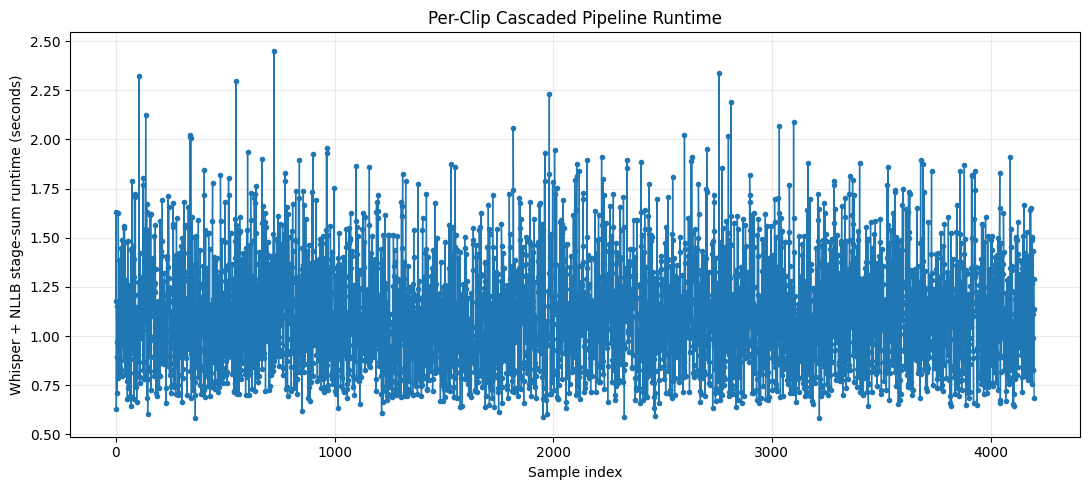

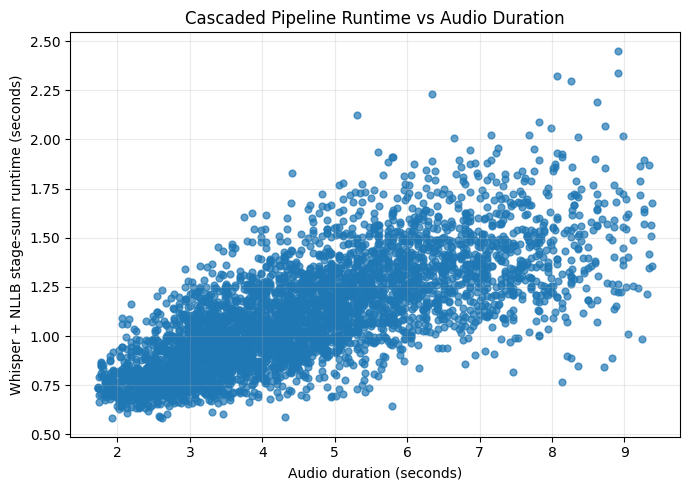

Saved runtime figure: /content/runs/cascade_run_1790228071/runtime_per_clip.png
Saved duration figure: /content/runs/cascade_run_1790228071/runtime_vs_audio_duration.png


In [19]:
plot_df = runtime_df.loc[success_mask].copy()
plot_df["sample_index"] = pd.to_numeric(plot_df["sample_index"], errors="coerce")
plot_df["cascade_stage_sum_runtime_sec"] = pd.to_numeric(
    plot_df["cascade_stage_sum_runtime_sec"], errors="coerce"
)
plot_df["audio_duration_sec"] = pd.to_numeric(
    plot_df["audio_duration_sec"], errors="coerce"
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    plot_df["sample_index"],
    plot_df["cascade_stage_sum_runtime_sec"],
    marker="o",
    markersize=3,
    linewidth=1,
)
ax.set(
    title="Per-Clip Cascaded Pipeline Runtime",
    xlabel="Sample index",
    ylabel="Whisper + NLLB stage-sum runtime (seconds)",
)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RUNTIME_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

duration_plot_df = plot_df.dropna(
    subset=["audio_duration_sec", "cascade_stage_sum_runtime_sec"]
)
if len(duration_plot_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        duration_plot_df["audio_duration_sec"],
        duration_plot_df["cascade_stage_sum_runtime_sec"],
        alpha=0.7,
        s=24,
    )
    ax.set(
        title="Cascaded Pipeline Runtime vs Audio Duration",
        xlabel="Audio duration (seconds)",
        ylabel="Whisper + NLLB stage-sum runtime (seconds)",
    )
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(DURATION_FIGURE_PATH, dpi=160, bbox_inches="tight")
    plt.show()

print(f"Saved runtime figure: {RUNTIME_FIGURE_PATH.resolve()}")
if DURATION_FIGURE_PATH.exists():
    print(f"Saved duration figure: {DURATION_FIGURE_PATH.resolve()}")


# 19. Save Run Summary and Final Reproducibility Record

The run summary mirrors the Direct pipeline but records both model stages, both exact model revisions, the staged execution strategy, runtime decomposition, generation diagnostics, fingerprints, and resource usage.


In [20]:
environment_info.update({
    "whisper_sample_rate_hz": WHISPER_SAMPLE_RATE,
    "peak_whisper_stage_gpu_memory_allocated_gb": runtime_summary[
        "peak_whisper_stage_gpu_memory_allocated_gb"
    ],
    "peak_nllb_stage_gpu_memory_allocated_gb": runtime_summary[
        "peak_nllb_stage_gpu_memory_allocated_gb"
    ],
    "peak_gpu_memory_allocated_gb": runtime_summary["peak_gpu_memory_allocated_gb"],
    "peak_gpu_memory_reserved_gb": runtime_summary["peak_gpu_memory_reserved_gb"],
})
ENVIRONMENT_PATH.write_text(
    json.dumps(environment_info, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
CONFIG_PATH.write_text(
    json.dumps(run_config, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

run_summary = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_started_utc": RUN_STARTED_UTC,
    "run_finished_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_mode": DATASET_MODE,
    "number_of_input_samples": len(metadata_df),

    "dataset_fingerprint": {
        "metadata_sha256": METADATA_SHA256_BEFORE,
        "ordered_id_sha256": ID_SHA256,
    },

    "architecture": "Whisper large-v2 ASR → NLLB-200 3.3B MT",
    "execution_strategy": EXECUTION_STRATEGY,

    "whisper_model_id": WHISPER_MODEL_ID,
    "requested_whisper_revision": WHISPER_MODEL_REVISION,
    "resolved_whisper_revision": RESOLVED_WHISPER_REVISION,
    "whisper_language": WHISPER_LANGUAGE,
    "whisper_task": WHISPER_TASK,
    "whisper_generation_settings": WHISPER_GENERATION_KWARGS,

    "nllb_model_id": NLLB_MODEL_ID,
    "requested_nllb_revision": NLLB_MODEL_REVISION,
    "resolved_nllb_revision": RESOLVED_NLLB_REVISION,
    "nllb_source_language": NLLB_SOURCE_LANGUAGE,
    "nllb_target_language": NLLB_TARGET_LANGUAGE,
    "nllb_generation_settings": NLLB_GENERATION_KWARGS,

    "decoding_policy_note": DECODING_POLICY_NOTE,
    "runtime_interpretation": (
        "Combined Cascade runtime is the sum of separately measured Whisper "
        "and NLLB per-sample stage runtimes; model load/warm-up excluded."
    ),

    "device": str(DEVICE),
    "gpu_name": GPU_NAME,
    "gpu_driver_version": GPU_DRIVER_VERSION,
    "git_commit": GIT_COMMIT,

    **runtime_summary,

    "output_files": {
        "predictions_csv": str(PREDICTIONS_PATH.resolve()),
        "runtime_csv": str(RUNTIME_PATH.resolve()),
        "environment_json": str(ENVIRONMENT_PATH.resolve()),
        "config_json": str(CONFIG_PATH.resolve()),
        "runtime_figure": str(RUNTIME_FIGURE_PATH.resolve()),
        "duration_figure": (
            str(DURATION_FIGURE_PATH.resolve())
            if DURATION_FIGURE_PATH.exists()
            else None
        ),
    },
}

SUMMARY_PATH.write_text(
    json.dumps(run_summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(f"Saved run summary: {SUMMARY_PATH.resolve()}")


Saved run summary: /content/runs/cascade_run_1790228071/run_summary.json


# 20. Final Validation

This cell mirrors the Direct notebook's integrity checks while adding Cascade-specific guarantees.

It verifies:

- prediction row count equals input row count;
- all original metadata columns/values are preserved;
- only `asr_transcript` and `cascade_translation` are appended;
- source metadata SHA-256 is unchanged;
- `sample_id` remains non-missing and unique;
- final 4,200 / 7 × 600 balance and audio invariants;
- runtime table contains exactly one complete row per input sample;
- every successful Cascade sample has both an ASR transcript and translation;
- ASR/MT failures have diagnostics;
- all required files exist.

Generation-cap flags are warnings for manual inspection rather than automatic evidence of truncation.


In [21]:
written_predictions = pd.read_csv(PREDICTIONS_PATH)
written_runtime = pd.read_csv(RUNTIME_PATH)
written_source_metadata = pd.read_csv(METADATA_PATH)

METADATA_SHA256_AFTER = sha256_file(METADATA_PATH)

final_balance_ok = True
final_audio_ok = True
if DATASET_MODE == "final":
    final_counts = written_source_metadata["primary_accent"].value_counts(dropna=False)
    final_balance_ok = (
        len(written_source_metadata) == EXPECTED_FINAL_SAMPLES
        and len(final_counts) == EXPECTED_FINAL_ACCENT_GROUPS
        and final_counts.eq(EXPECTED_FINAL_SAMPLES_PER_ACCENT).all()
    )
    final_audio_ok = bool(audio_exists.all() and duplicate_audio_count == 0)

runtime_indices = pd.to_numeric(
    written_runtime["sample_index"], errors="coerce"
).dropna().astype(int)

success_indices = pd.to_numeric(
    written_runtime.loc[
        written_runtime["cascade_status"].eq("success"),
        "sample_index",
    ],
    errors="coerce",
).dropna().astype(int)

asr_failed = written_runtime["asr_status"].eq("failed")
mt_failed = written_runtime["mt_status"].eq("failed")

validation_checks = {
    "prediction_rows_match_input": len(written_predictions) == len(metadata_df),
    "original_columns_preserved": all(
        c in written_predictions.columns for c in original_columns
    ),
    "original_column_order_preserved": (
        written_predictions.columns.tolist()[1:1 + len(original_columns)]
        == original_columns
    ),

    "only_expected_columns_present": (
        written_predictions.columns.tolist()
        == [
            "id",
            *original_columns,
            "asr_transcript",
            "cascade_translation",
        ]
    ),
    "source_metadata_values_preserved": written_predictions[
        original_columns
    ].equals(written_source_metadata[original_columns]),

    "source_metadata_sha256_unchanged": (
        METADATA_SHA256_AFTER == METADATA_SHA256_BEFORE
    ),
    "id_nonmissing": (
        written_predictions["id"].notna().all()
        and written_predictions["id"]
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),

    "id_unique": written_predictions["id"].is_unique,

    "sample_id_nonmissing": (
        written_source_metadata["sample_id"].notna().all()
        and written_source_metadata["sample_id"]
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),

    "final_dataset_size_and_balance_valid": final_balance_ok,
    "final_audio_complete_and_unique": final_audio_ok,

    "runtime_rows_match_input": len(written_runtime) == len(metadata_df),
    "runtime_sample_index_complete_and_unique": (
        len(runtime_indices) == len(metadata_df)
        and runtime_indices.nunique() == len(metadata_df)
        and set(runtime_indices) == set(range(len(metadata_df)))
    ),

    "runtime_csv_exists": RUNTIME_PATH.is_file(),
    "required_output_files_exist": all(
        p.is_file()
        for p in [
            PREDICTIONS_PATH,
            RUNTIME_PATH,
            ENVIRONMENT_PATH,
            CONFIG_PATH,
            SUMMARY_PATH,
            RUNTIME_FIGURE_PATH,
        ]
    ),

    "all_successes_have_asr_transcript": (
        written_predictions.loc[success_indices, "asr_transcript"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),
    "all_successes_have_non_degenerate_asr": all(
        not is_degenerate_transcript(text)[0]
        for text in written_predictions.loc[success_indices, "asr_transcript"]
    ),
    "all_successes_have_cascade_translation": (
        written_predictions.loc[success_indices, "cascade_translation"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),
    "asr_failures_have_diagnostics": (
        written_runtime.loc[asr_failed, "asr_error"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),
    "mt_failures_have_diagnostics": (
        written_runtime.loc[mt_failed, "mt_error"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),
}

validation_df = pd.Series(validation_checks, name="passed").to_frame()
display(validation_df)

if not all(validation_checks.values()):
    failed_checks = [
        name for name, passed in validation_checks.items() if not passed
    ]
    raise AssertionError(f"Final validation failed: {failed_checks}")

whisper_limit_hit_count = int(
    written_runtime.loc[
        written_runtime["cascade_status"].eq("success"),
        "whisper_generation_limit_reached",
    ]
    .fillna(False)
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
    .sum()
)
nllb_limit_hit_count = int(
    written_runtime.loc[
        written_runtime["cascade_status"].eq("success"),
        "nllb_generation_limit_reached",
    ]
    .fillna(False)
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
    .sum()
)

if whisper_limit_hit_count:
    warnings.warn(
        f"{whisper_limit_hit_count} successful Cascade sample(s) have a "
        "conservative Whisper generation-limit flag."
    )
else:
    print("Whisper generation-limit diagnostic: no flagged successful outputs ✓")

if nllb_limit_hit_count:
    warnings.warn(
        f"{nllb_limit_hit_count} successful Cascade sample(s) have a "
        "conservative NLLB generation-limit flag."
    )
else:
    print("NLLB generation-limit diagnostic: no flagged successful outputs ✓")

print(f"Metadata SHA-256 unchanged: {METADATA_SHA256_BEFORE == METADATA_SHA256_AFTER}")
print("Final validation passed: Cascade outputs are complete, reproducible, and structurally consistent.")


,passed
prediction_rows_match_input,True
original_columns_preserved,True
original_column_order_preserved,True
only_expected_columns_present,True
source_metadata_values_preserved,True
source_metadata_sha256_unchanged,True
id_nonmissing,True
id_unique,True
sample_id_nonmissing,True
final_dataset_size_and_balance_valid,True


Whisper generation-limit diagnostic: no flagged successful outputs ✓
NLLB generation-limit diagnostic: no flagged successful outputs ✓
Metadata SHA-256 unchanged: True
Final validation passed: Cascade outputs are complete, reproducible, and structurally consistent.


# 21. Final Run Summary

The final cell prints a compact handoff summary for the later evaluation notebooks.

It includes:

- dataset/model identity;
- exact model revisions;
- completion status;
- Whisper and NLLB stage timings;
- combined stage-sum timing;
- RTF;
- generation-limit diagnostics;
- peak GPU memory;
- output file paths.

The output makes it easy to confirm that the Cascaded inference run is ready for downstream WER/chrF++/BLEU evaluation.


In [22]:
def format_number(value, decimals=3):
    return "N/A" if value is None or pd.isna(value) else f"{value:.{decimals}f}"

print(f"Dataset mode: {DATASET_MODE.upper()}")
print("Architecture: Whisper large-v2 ASR → NLLB-200 3.3B MT")
print(f"Whisper: {WHISPER_MODEL_ID}")
print(f"Whisper revision: {RESOLVED_WHISPER_REVISION}")
print(f"NLLB: {NLLB_MODEL_ID}")
print(f"NLLB revision: {RESOLVED_NLLB_REVISION}")
print(f"Direction: English speech → English ASR → Chinese ({NLLB_TARGET_LANGUAGE})")
print(f"Device: {DEVICE}")
print(f"GPU: {GPU_NAME or 'N/A'}")
print(f"GPU driver: {GPU_DRIVER_VERSION or 'N/A'}")
print()

print(f"Samples: {runtime_summary['total_samples']:,}")
print(f"Successful: {runtime_summary['successful_samples']:,}")
print(f"Failed: {runtime_summary['failed_samples']:,}")
print(f"Whisper generation-limit flags: {runtime_summary['whisper_generation_limit_hits']:,}")
print(f"NLLB generation-limit flags: {runtime_summary['nllb_generation_limit_hits']:,}")
print()

print(
    "Total Whisper stage runtime: "
    f"{format_number(runtime_summary['total_whisper_runtime_sec'])} sec"
)
print(
    "Total NLLB stage runtime: "
    f"{format_number(runtime_summary['total_nllb_runtime_sec'])} sec"
)
print(
    "Total Cascade stage-sum runtime: "
    f"{format_number(runtime_summary['total_cascade_stage_sum_runtime_sec'])} sec"
)
print(
    "Mean Cascade stage-sum sec/sample: "
    f"{format_number(runtime_summary['mean_cascade_stage_sum_runtime_sec'])}"
)
print(
    "Median Cascade stage-sum sec/sample: "
    f"{format_number(runtime_summary['median_cascade_stage_sum_runtime_sec'])}"
)
print(
    "Mean Whisper generation sec/sample: "
    f"{format_number(runtime_summary['mean_whisper_generation_runtime_sec'])}"
)
print(
    "Mean NLLB generation sec/sample: "
    f"{format_number(runtime_summary['mean_nllb_generation_runtime_sec'])}"
)
print(f"Mean Cascade RTF: {format_number(runtime_summary['mean_realtime_factor'])}")
print(
    "Overall staged peak GPU memory allocated: "
    f"{format_number(runtime_summary['peak_gpu_memory_allocated_gb'])} GB"
)
print()

print("Runtime note: combined Cascade time is Whisper + NLLB stage-sum; model loading/warm-up excluded.")
print(f"Metadata SHA-256: {METADATA_SHA256_BEFORE}")
print(f"id SHA-256: {ID_SHA256}")
print(f"Git commit: {GIT_COMMIT or 'N/A'}")
print()

print(f"Predictions: {PREDICTIONS_PATH.resolve()}")
print(f"Runtime details: {RUNTIME_PATH.resolve()}")
print(f"Environment: {ENVIRONMENT_PATH.resolve()}")
print(f"Run config: {CONFIG_PATH.resolve()}")
print(f"Run summary: {SUMMARY_PATH.resolve()}")
print(f"Figures: {RUNTIME_FIGURE_PATH.resolve()}")
print("\nCASCADED RUN COMPLETED AND VALIDATED.")


Dataset mode: FINAL
Architecture: Whisper large-v2 ASR → NLLB-200 3.3B MT
Whisper: openai/whisper-large-v2
Whisper revision: ae4642769ce2ad8fc292556ccea8e901f1530655
NLLB: facebook/nllb-200-3.3B
NLLB revision: 1a07f7d195896b2114afcb79b7b57ab512e7b43e
Direction: English speech → English ASR → Chinese (zho_Hans)
Device: cuda
GPU: Tesla T4
GPU driver: 580.82.07

Samples: 4,200
Successful: 4,200
Failed: 0
Whisper generation-limit flags: 0
NLLB generation-limit flags: 0

Total Whisper stage runtime: 3085.347 sec
Total NLLB stage runtime: 1564.801 sec
Total Cascade stage-sum runtime: 4650.148 sec
Mean Cascade stage-sum sec/sample: 1.107
Median Cascade stage-sum sec/sample: 1.074
Mean Whisper generation sec/sample: 0.708
Mean NLLB generation sec/sample: 0.371
Mean Cascade RTF: 0.256
Overall staged peak GPU memory allocated: 11.126 GB

Runtime note: combined Cascade time is Whisper + NLLB stage-sum; model loading/warm-up excluded.
Metadata SHA-256: 57fb7e6b62647d661cb887bdd279f1b4af57bbf1fca8e

# 22. Zip Run Results — Google Colab Only

After final validation and the run summary, archive the current `RUN_DIR` into `/content/<run_directory_name>.zip`. The ZIP includes the run directory itself and all saved predictions, diagnostics, JSON records, and figures. Its integrity is checked before the archive path is printed.

This step runs **only in a Google Colab environment** and automatically skips elsewhere. Run it in the same kernel as the pipeline so `RUN_DIR` identifies the intended run. Rerunning it replaces the ZIP for that run. Copy or download the archive before ending the runtime; creating it under `/content` does not provide a persistent backup. Save the executed notebook separately.


In [23]:
import shutil
from pathlib import Path
from zipfile import ZipFile

try:
    import google.colab
    archive_in_colab = True
except ImportError:
    archive_in_colab = False

if not archive_in_colab:
    print("Results archiving skipped: this is not a Google Colab environment.")
else:
    if not RUN_DIR.is_dir():
        raise FileNotFoundError(f"Run directory missing: {RUN_DIR}")

    archive_path = Path(shutil.make_archive(
        str(Path('/content') / RUN_DIR.name),
        'zip',
        root_dir=RUN_DIR.parent,
        base_dir=RUN_DIR.name,
    ))
    with ZipFile(archive_path) as archive:
        assert archive.testzip() is None, 'Archive integrity check failed.'
    print('Results archive:', archive_path)


Results archive: /content/cascade_run_1790228071.zip
